02_preprocessing.ipynb

##Task2 - Feature Engineering & Preprocessing

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn (1).csv


In [2]:
import pandas as pd
df = pd.read_csv('/content/Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [4]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges'],
      dtype='object')
Numerical: Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')


In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in categorical_cols:
    if X[col].nunique() == 2:
        X[col] = le.fit_transform(X[col])

In [6]:
X = pd.get_dummies(X, drop_first=True)

Label Encoding → used for binary features (efficient) One-Hot Encoding → used for multi-category (avoids ordinal bias)

STANDARDSCALAR

In [7]:
from sklearn.preprocessing import StandardScaler

scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X)

MINMAXSCALAR

In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler_mm = MinMaxScaler()
X_mm = scaler_mm.fit_transform(X)

StandardScaler → good for models like Logistic Regression
MinMaxScaler → keeps values between 0 and 1

In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [10]:
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

/tmp/ipykernel_7645/2840544469.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [11]:
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)

In [12]:
services = ['PhoneService','MultipleLines','InternetService',
            'OnlineSecurity','OnlineBackup','DeviceProtection',
            'TechSupport','StreamingTV','StreamingMovies']


In [13]:
df['ServiceCount'] = df[services].apply(lambda x: sum(x == 'Yes'), axis=1)

In [14]:
df['ContractValue'] = df['MonthlyCharges'] * df['tenure']

AvgMonthlySpend → spending behavior ServiceCount → engagement level ContractValue → revenue contribution

COLLERATION

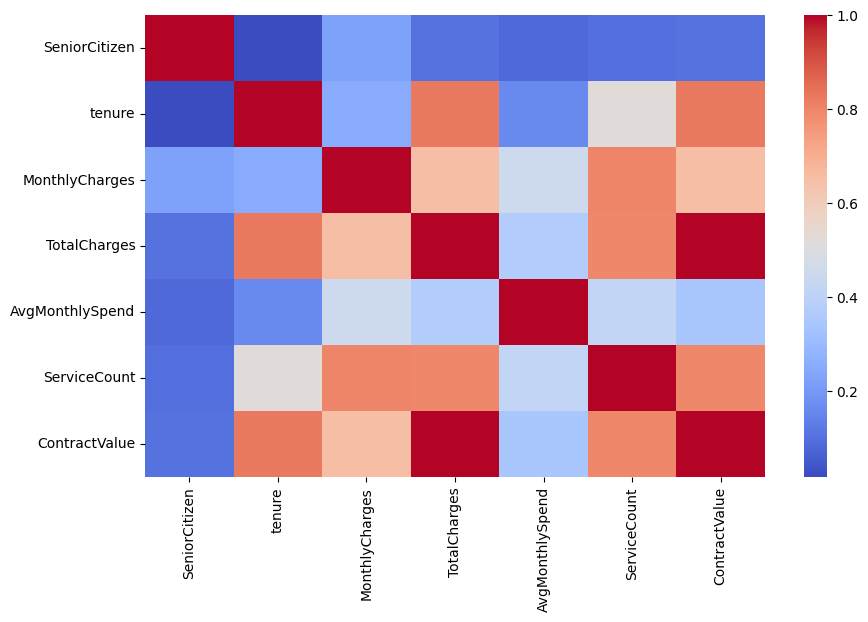

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

FEATURE IMPORTANCE

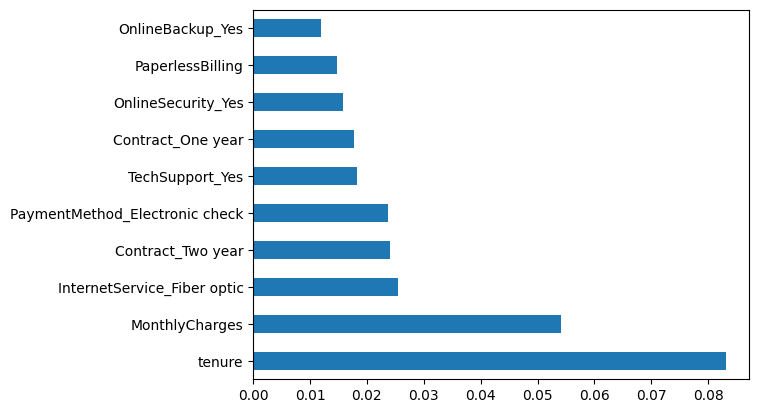

In [17]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.show()

Correlation removes redundant features
Tree-based importance selects most impactful features

SMOTE

In [18]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_sm, y_sm = smote.fit_resample(X, y)

CLASS WEIGHTS

In [19]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weights = dict(enumerate(weights))

print(class_weights)

{0: np.float64(0.6806146115191342), 1: np.float64(1.8841626538255751)}


SMOTE → creates synthetic samples
Class weights → penalizes imbalance during training

In [20]:
from sklearn.model_selection import train_test_split


In [21]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42)

In [22]:
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=42)

70% TRAIN
15% VALIDATION
15%TEST